## Slides RL 1

Starting a new notebook for the RL portion of the slides!

In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle
# from pathlib import Path

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_gold", [BLUE, YELLOW], N=256)

In [3]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)


def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

In [4]:
# HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'
HACKIN_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/rl_1/hackin'

In [5]:
VEL_SCALE = 10   # divide all velocities by 10 -> feature scales comparable, ~isotropic parameter space

In [6]:
# with open(HACKIN_DIR+"/cartpole_human_play/cartpole_human_demos_sw_3.json") as f: #This one has some pretty good runs from SW
#     data = json.load(f)

# with open(HACKIN_DIR/"cartpole_human_play/cartpole_human_demos_pranav_4.json") as f: 
#     data = json.load(f) 

# for ep in data["episodes"]:
#     o = np.array(ep["observations"], dtype=np.float64)
#     o[:, 1] /= VEL_SCALE   # cart velocity
#     o[:, 3] /= VEL_SCALE   # pole angular velocity
#     ep["observations"] = o

# print(len(data["episodes"]))

In [7]:
CART_W, CART_H, POLE_LEN, WHEEL_R = 0.5, 0.26, 1.0, 0.07

def draw_cartpole(ax, cart_x, pole_theta, action=None):
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-0.55, 1.75)
    ax.set_aspect('equal'); ax.axis('off')
    ax.plot([-2.4, 2.4], [0, 0], color=CHILL_BROWN, lw=1.5, zorder=1)   # track
    cart_y = WHEEL_R*2
    for dx in (-CART_W*0.3, CART_W*0.3):
        ax.add_patch(Circle((cart_x+dx, WHEEL_R), WHEEL_R, color=CHILL_BROWN, zorder=3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 fc='#3a3a3a', ec=CHILL_BROWN, lw=1.5, zorder=4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)],
            [py, py + POLE_LEN*np.cos(pole_theta)],
            color='w', lw=6, solid_capstyle='round', zorder=5)
    ax.add_patch(Circle((px, py), 0.045, color=CHILL_BROWN, zorder=6))
    if action is not None:   # action arrow under the cart, your color convention
        ax.scatter([cart_x], [-0.32],
                   marker=(RIGHT_ARROW if action==1 else LEFT_ARROW), s=420,
                   color=(YELLOW if action==1 else BLUE), linewidths=0, zorder=5)

In [8]:
RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

ANG_LIM = (-13, 13) #Ok I want this to be in degrees!
VEL_LIM = (-17, 17)   # angvel data is pre-divided by VEL_SCALE=10

## 0. Compute Average Return Surface

In [12]:
class Pi(nn.Module):
    """Two-parameter policy: logit = theta1 * pole_angle + theta2 * pole_ang_velocity.

    P(right) = sigmoid(logit). Returns [P(left), P(right)] with shape (2,) or (T, 2),
    so the REINFORCE loop below is unchanged from the neural net version.
    """
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))  # [theta1, theta2] -> uniform random policy at init

    def forward(self, x):
        feats = x[..., 2:4]                # state indices 2, 3: pole angle, pole angular velocity
        logit = feats @ self.theta         # scalar or (T,)
        p_right = torch.sigmoid(logit)
        return torch.stack([1.0 - p_right, p_right], dim=-1)

In [13]:
def scale_state(s):
    s = s.astype(np.float32).copy()
    s[1] /= VEL_SCALE; s[3] /= VEL_SCALE   # same /10 velocity scaling as the demo data
    return s

def run_rollout(seed, deterministic=False):
    # --- rollout: collect one episode ---
    states, actions, rewards = [], [], []
    state, _ = env.reset(seed=seed)
    state = scale_state(state)
    for t in range(500):                                # CartPole-v1 max timestep is 500
        with torch.no_grad():                           # no graph needed here; we recompute below
            probs = pi(torch.from_numpy(state))

        if deterministic:
            action=probs.argmax().item() #Armax instead of sample!
        else:
            action = np.random.choice(out_dim, p=probs.numpy())

        states.append(state)                            # note: stored states are velocity-scaled
        actions.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        state = scale_state(state)
        rewards.append(reward)
        if terminated or truncated:
            break

    return states, actions, rewards

### 0.1 Quick Performance Baseline

In [31]:
env = gym.make('CartPole-v1')
out_dim = env.action_space.n              
gamma=1.0

torch.manual_seed(52)
np.random.seed(52)
pi = Pi()

pi.theta=nn.Parameter(torch.tensor([0.1, 0.2]))

# optimizer = optim.Adam(pi.parameters(), lr=0.05)  # 2 params only -> larger lr than the NN version
optimizer = optim.SGD(pi.parameters(), lr=0.007)  # plain SGD: steps follow raw gradient direction (better for viz)

In [32]:
total_rewards = []

for epi in tqdm(range(500)):

    states, actions, rewards = run_rollout(seed=epi)
    # --- discounted returns-to-go: G_t = r_t + gamma * G_{t+1}, computed backwards ---
    T = len(rewards)
    rets = np.empty(T, dtype=np.float32)
    future_ret = 0.0
    for t in reversed(range(T)):
        future_ret = rewards[t] + gamma * future_ret
        rets[t] = future_ret
    rets = torch.tensor(rets)
    
    # rets = (rets - rets.mean()) / (rets.std() + 1e-8)   # baseline + variance normalization

    # --- REINFORCE update: one batched forward over the whole episode ---
    state_batch = torch.tensor(np.array(states, dtype=np.float32))   # (T, 4)
    action_batch = torch.tensor(actions)                              # (T,)
    prob_batch = pi(state_batch)                                      # (T, 2)
    act_probs = prob_batch[torch.arange(T), action_batch]             # prob of each action actually taken
    
    loss = -(torch.log(act_probs) * rets).sum()
    # loss = -(act_probs * rets).sum()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_rewards.append(sum(rewards))

100%|████████████████████████████████████████| 500/500 [00:01<00:00, 287.41it/s]


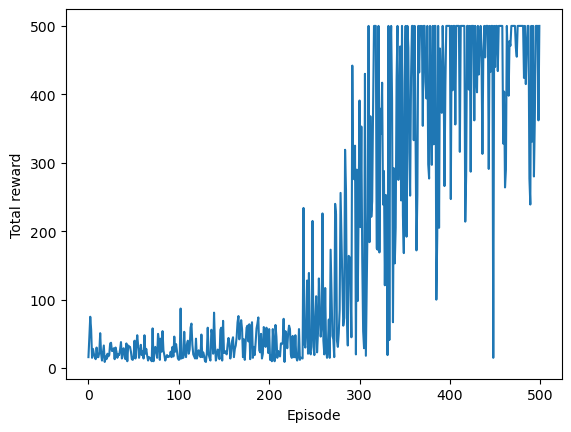

In [33]:
plt.plot(total_rewards)
plt.xlabel('Episode')
plt.ylabel('Total reward');

## 0.2 Run Sweep
- Running longer ones in other notebooks!

In [42]:
num_samples=32
num_steps=32

theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

all_rewards=[]

for t1 in tqdm(theta1_vals_viz):
    all_rewards.append([])
    for t2 in theta2_vals_viz:
        all_rewards[-1].append([])
        for i in range(num_samples):
            pi = Pi()
            pi.theta=nn.Parameter(torch.tensor([t1.item(), t2.item()]))
            states, actions, rewards = run_rollout(seed=i, deterministic=True) 
            all_rewards[-1][-1].append(np.sum(rewards).item())
all_rewards=np.array(all_rewards)

100%|███████████████████████████████████████████| 32/32 [00:50<00:00,  1.57s/it]


In [51]:
#Load from disk
all_rewards = np.load(HACKIN_DIR+'/64_32_det_1.npy')

In [54]:
all_rewards.shape

(64, 64, 32)

In [52]:
avg_reward=np.mean(all_rewards, 2)
std_reward=np.std(all_rewards, 2)

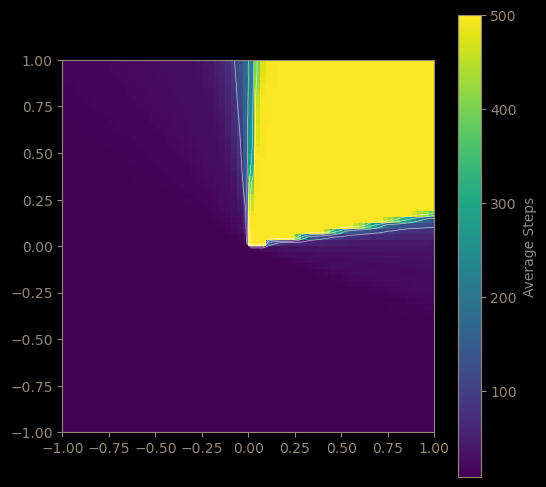

In [62]:
num_steps=all_rewards.shape[0]
theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)
extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
im = ax.imshow(avg_reward.T, origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = ax.contour(T1, T2, avg_reward.T, levels=5, colors='w', linewidths=0.5, alpha=0.7)
cb = fig.colorbar(im, ax=ax)
style_ax(ax)
cb.set_label('Average Steps', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)

## 1. State Space and Cart Rollouts Animations and statistics from each quadrant

- Ok, let's see here, kind of alot going on for this visualization.
- So I'll need to export 8 sets of pngs, and 4 histograms.
- Let's take 4 points in parameter space `(-0.5, 0.5), (-0.5, 0.5), (0.5, -0.5), (0.5, 0.5)`
- For the crappy points (first 3), run 12 rollouts. For Final point I think we only need 1-2 b/c it should run for 500!
- Now, for each configuration, export the left/right states space rollouts like we did in first notebook. Reset after each rollout. Include model's output as heatmap on top as we did before. In separate folder export the cartpole animation, with the number of steps!
- Finally, for each configuration, export a histogram of runs (same style as previous notebook), rerun with 256 samples for each. 

### 1.0 Quadrant configs + rollouts
- Four points in parameter space, one per quadrant of the return surface, in plot (per-degree) units.
- NOTE: spec above lists `(-0.5, 0.5)` twice -- assuming the intended set is the four quadrants.
- Sanity-checked deterministic performance at each point: (-,-) ~9 steps, (-,+) ~15, (+,-) ~10, (+,+) = 500 on every seed tested. So (+,+) is the "final point" and 2 rollouts is plenty.

In [63]:
import os

env = gym.make('CartPole-v1')
out_dim = env.action_space.n

# points are in plot (per-degree) units, matching the return surface axes in 0.2.
# model's native theta is per-radian -> theta_native = np.degrees(theta_plot)
QUAD_CONFIGS = [
    {'name': 'neg_neg', 'theta_plot': (-0.5, -0.5), 'n_rollouts': 12},
    {'name': 'neg_pos', 'theta_plot': (-0.5,  0.5), 'n_rollouts': 12},
    {'name': 'pos_neg', 'theta_plot': ( 0.5, -0.5), 'n_rollouts': 12},
    {'name': 'pos_pos', 'theta_plot': ( 0.5,  0.5), 'n_rollouts': 2},   # hits 500 every time -> 1-2 is plenty
]

def set_theta_plot(t1_plot, t2_plot):
    with torch.no_grad():
        pi.theta[:] = torch.tensor([np.degrees(t1_plot), np.degrees(t2_plot)]).float()

pi = Pi()
for cfg in QUAD_CONFIGS:
    set_theta_plot(*cfg['theta_plot'])
    episodes = []
    for seed in range(cfg['n_rollouts']):   # env reset with a fresh seed for every rollout
        states, actions, rewards = run_rollout(seed=seed, deterministic=True)
        episodes.append({'obs': np.array(states), 'act': np.array(actions), 'steps': len(rewards)})
    cfg['episodes'] = episodes
    print(f"{cfg['name']}  theta_plot={cfg['theta_plot']}  steps:", [e['steps'] for e in episodes])

neg_neg  theta_plot=(-0.5, -0.5)  steps: [8, 9, 9, 9, 8, 9, 9, 9, 9, 9, 9, 9]
neg_pos  theta_plot=(-0.5, 0.5)  steps: [11, 13, 13, 14, 11, 24, 19, 15, 18, 19, 13, 22]
pos_neg  theta_plot=(0.5, -0.5)  steps: [11, 10, 10, 10, 10, 9, 10, 10, 10, 10, 10, 9]
pos_pos  theta_plot=(0.5, 0.5)  steps: [500, 500]


In [64]:
def anim_frames(T, dense_steps=40, max_frames=150):
    # every step for the first dense_steps, then evenly-spaced steps so the 500-step
    # episodes don't generate thousands of frames -- reads as a fast-forward
    if T <= max_frames:
        return np.arange(T)
    tail = np.linspace(dense_steps, T-1, max_frames - dense_steps).astype(int)
    return np.unique(np.concatenate([np.arange(dense_steps), tail]))

print('total frames ~', sum(len(anim_frames(len(e['act']))) for cfg in QUAD_CONFIGS for e in cfg['episodes']))

total frames ~ 717


In [65]:
def draw_state_panel(ax, cfg, obs_e, act_e, t, made_it):
    """State-space panel: model output heatmap + decision boundary + rollout so far."""
    t1, t2 = cfg['theta_plot']   # per-degree units -> pair directly with degree axes
    ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])

    A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
    P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
    ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
              extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
    ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)

    m = act_e[:t+1] == 1
    a, v = ang[:t+1], angvel[:t+1]
    ax.scatter(a[m],  v[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
    ax.scatter(a[~m], v[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0)

    is_terminal = (t == len(act_e)-1)
    ring_color = RED if (is_terminal and not made_it) else 'w'   # red ring only on actual failure
    ax.scatter([ang[t]], [angvel[t]],
               marker=(RIGHT_ARROW if act_e[t]==1 else LEFT_ARROW), s=260,
               facecolors='none', edgecolors=ring_color, linewidths=1.6, zorder=5)

    ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
    ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity') # (degrees/s / 10)
    ax.set_title('State Space'); style_ax(ax)

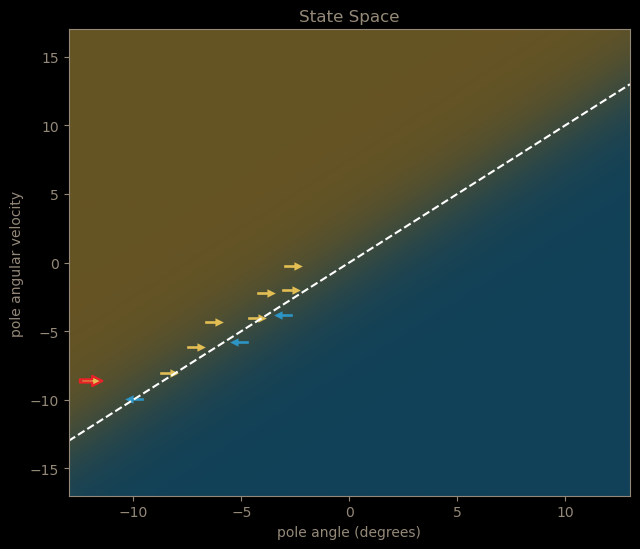

In [66]:
# ---- quick single-frame check before the big export ----
cfg = QUAD_CONFIGS[1]   # neg_pos
ep_idx, t = 0, cfg['episodes'][0]['steps'] - 1
obs_e, act_e = cfg['episodes'][ep_idx]['obs'], cfg['episodes'][ep_idx]['act']
made_it = cfg['episodes'][ep_idx]['steps'] == 500

fig, ax = plt.subplots(figsize=(6.5, 5.6), facecolor='k')
ax.set_facecolor('k')
draw_state_panel(ax, cfg, obs_e, act_e, t, made_it)
plt.tight_layout()

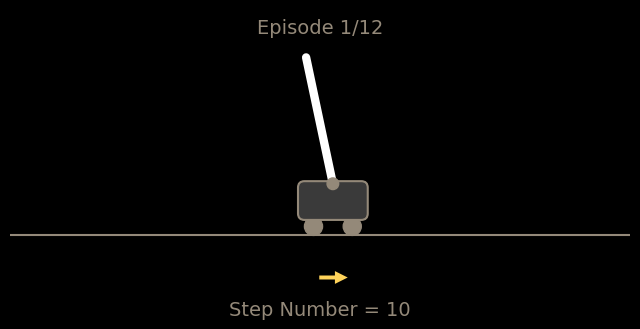

In [67]:
fig, ax = plt.subplots(figsize=(6.5, 5.6), facecolor='k')
ax.set_facecolor('k')
draw_cartpole(ax, obs_e[t,0], obs_e[t,2], action=act_e[t])
ax.text(0, -0.5, f'Step Number = {t}', ha='center', va='top', color=CHILL_BROWN, fontsize=14)
ax.text(0, 1.68, f'Episode {ep_idx+1}/{len(cfg["episodes"])}', ha='center', va='top', color=CHILL_BROWN, fontsize=14)
plt.tight_layout()

### 1.1 Export state space + cartpole animation frames
- Two folders per config (8 total): `quadrant_<name>_state_space_1` and `quadrant_<name>_cartpole_1`.
- Frame filenames match 1:1 across the two folders (terminal hold included in both), so the sequences stay synced in editing.

In [70]:
TERMINAL_HOLD = 7

for cfg in QUAD_CONFIGS:
    ss_dir = HACKIN_DIR + f"/quadrant_{cfg['name']}_state_space_1"
    cp_dir = HACKIN_DIR + f"/quadrant_{cfg['name']}_cartpole_1"
    os.makedirs(ss_dir, exist_ok=True); os.makedirs(cp_dir, exist_ok=True)

    GLOBAL_COUNT = 0
    for ep_idx, ep in enumerate(tqdm(cfg['episodes'], desc=cfg['name'])):
        obs_e, act_e = ep['obs'], ep['act']
        made_it = ep['steps'] == 500

        for t in anim_frames(len(obs_e)):
            is_terminal = (t == len(act_e)-1)
            reps = 1 + (TERMINAL_HOLD if is_terminal else 0)

            # ---- state space frame (rollout so far resets each episode) ----
            figS, axS = plt.subplots(figsize=(6.5, 5.6), facecolor='k')
            axS.set_facecolor('k')
            draw_state_panel(axS, cfg, obs_e, act_e, t, made_it)
            figS.tight_layout()

            # ---- cartpole frame, with step counter ----
            figC, axC = plt.subplots(figsize=(6.5, 5.6), facecolor='k')
            axC.set_facecolor('k')
            draw_cartpole(axC, obs_e[t,0], obs_e[t,2], action=act_e[t])
            axC.text(0, -0.5, f'Step Number = {t}', ha='center', va='top', color=CHILL_BROWN, fontsize=14)
            axC.text(0, 1.68, f'Episode {ep_idx+1}/{len(cfg["episodes"])}', ha='center', va='top', color=CHILL_BROWN, fontsize=14)
            figC.tight_layout()

            for k in range(reps):
                figS.savefig(ss_dir + '/' + str(GLOBAL_COUNT).zfill(4) + '.png', dpi=240, facecolor='k')
                figC.savefig(cp_dir + '/' + str(GLOBAL_COUNT).zfill(4) + '.png', dpi=240, facecolor='k')
                GLOBAL_COUNT += 1
            plt.close(figS); plt.close(figC)

pos_pos: 100%|████████████████████████████████████| 2/2 [00:57<00:00, 28.58s/it]


### 1.2 Histograms
- 256 deterministic rollouts per config, same style as previous notebook.

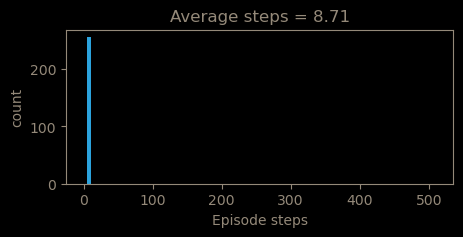

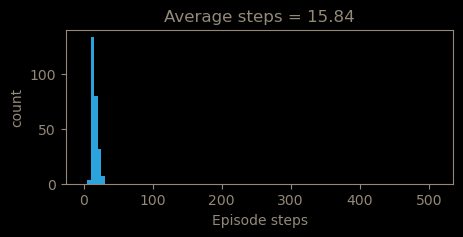

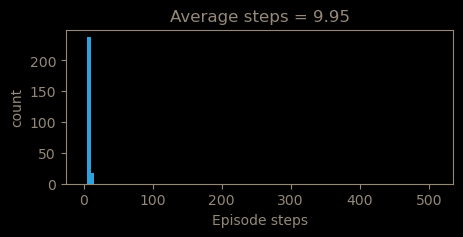

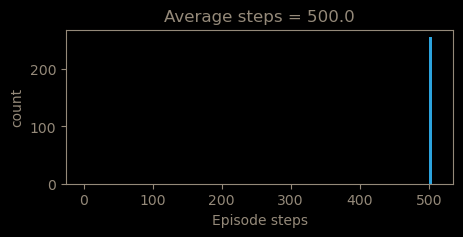

In [75]:
for cfg in QUAD_CONFIGS:
    set_theta_plot(*cfg['theta_plot'])
    rewardz = []
    for i in range(256):
        states, actions, rewards = run_rollout(seed=i, deterministic=True)
        rewardz.append(np.sum(rewards))
    cfg['rewardz'] = rewardz

    fig, ax = plt.subplots(figsize=(5,2), facecolor='k')
    ax.set_facecolor('k')
    ax.hist(rewardz, bins=np.linspace(0, 510, 101), color=BLUE)
    ax.set_title('Average steps = ' + str(round(np.mean(rewardz), 2)))
    ax.set_xlabel('Episode steps'); ax.set_ylabel('count')
    style_ax(ax)   # CHILL_BROWN spines, ticks, labels, title
    plt.savefig(f"quadrant_{cfg['name']}_hist.png", dpi=240)
    plt.show()
    plt.close(fig)